# 09 · Analysis on full sample (archive ↔ merged)

Replicates the structure of `temp/reference_code/14.analysis_full_sample.ipynb`
but runs on **both** the archived regression-core dataset (981 docs, 2015-2023)
and the merged incremental dataset (1,101 docs = 981 archived + 120 new
2024-2025 rows) so charts are shown side-by-side. The goal is twofold:

1. Make the expanded incremental sample visible to downstream users.
2. Surface any drift introduced by adding the 120 new docs.

Inputs:
- `df_fin_reg_core.csv` (archive) — frozen 2015-2023 reference
- `df_fin_reg_core_merged.csv` (merged) — archive + 120 incremental rows
- `df_documents_general.csv` (archive) and `df_documents_general_merged.csv` —
  for the zero-shot per-sector disagreement-area lists
- `docs/reference/country_meta_info.xlsx` — for `Income` (income group) lookup

See [the plan](../../../../.claude/plans/pwd-purrfect-zephyr.md) for details.

In [1]:
# --- Imports ---
import sys, ast, itertools, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

# Make data_vis_utils importable
_TRACTION = Path('/data/home/xiong/dev/Fund_ISR/src/Traction')
if str(_TRACTION) not in sys.path:
    sys.path.insert(0, str(_TRACTION))
from post_estimate_analysis import data_vis_utils as dvu
from post_estimate_analysis.classify_disagreement_areas import classify_areas_batch, PREFIX_TO_SECTOR

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

# --- Colors (ported verbatim from reference notebook cell 0) ---
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

_rdbu = plt.get_cmap('RdBu')
colors11 = [_rdbu(i/12) for i in range(11, 0, -1)]
colors7  = [_rdbu(i/8)  for i in range(7,  0, -1)]
colors6  = [_rdbu(i/7)  for i in range(6,  0, -1)]
colors3  = [_rdbu(i/4)  for i in range(3,  0, -1)]

_paired = plt.get_cmap('Paired')
colors_cate = [_paired(i) for i in range(12)]
colors_cate = [colors_cate[i + 1] if i % 2 == 0 else colors_cate[i - 1] for i in range(len(colors_cate))]

plt.rcParams['figure.figsize'] = (10, 7)

In [2]:
# --- Constants ported from reference notebook ---

# Stance numeric encodings (cells 39, 56). Same scale used for monetary future
# and fiscal near-term direction.
STANCE_FUTURE_DICT = {
    'tightening': 5,
    'tightening bias': 4,
    'no change': 3,
    'loosening bias': 2,
    'loosening': 1,
}
# Monetary current stance (cell 39)
STANCE_CURRENT_DICT = {
    'accommodative': 0,
    'neutral': 1,
    'restrictive': 2,
}

# Policy-mix label (cells 77, 78)
POLICY_MIX_9 = ['MtFt', 'MnFt', 'MlFt', 'MtFn', 'MnFn', 'MlFn', 'MtFl', 'MnFl', 'MlFl']
STANCE_LABELS_5 = ['tightening', 'tightening bias', 'no change / unclear', 'loosening bias', 'loosening']

# Income-group ordering — matches data_vis_utils default groups
INCOME_GROUPS = ('ALL', 'AE', 'EM', 'LIC')

## 1 · Load + enrich

Loads the two regression-core datasets and the two zero-shot general-agreement
datasets. Then:

- Normalises `Print ISBN` dtypes (archive stores as float64, incremental as
  int64; strips trailing `.0` so they compare as strings).
- Merges `Income` (income group) from `country_meta_info.xlsx` on
  `Primary Country Code = ISO3`.
- Coalesces the new merged general-agreement file's columns: legacy
  `Monetary_gpt`/`Fiscal_gpt`/... (from archived rows) and new
  `Monetary_Sector`/`Fiscal_Sector`/... (from incremental rows) are both
  present but mutually-exclusive per row. Coalesce so downstream code only
  sees one set of column names.

In [4]:
# --- Paths ---
ARC_DIR    = Path('/data/home/xiong/data/Fund/CSR/Traction-archieve/output')
MERGED_DIR = Path('/data/home/xiong/data/Fund/CSR/Tractions/output/incremental_update/06_07_2026_update')
META_PATH  = _TRACTION / 'docs' / 'reference' / 'country_meta_info.xlsx'

print(f'archive dir : {ARC_DIR}')
print(f'merged dir  : {MERGED_DIR}')
print(f'meta xlsx   : {META_PATH}')

archive dir : /data/home/xiong/data/Fund/CSR/Traction-archieve/output
merged dir  : /data/home/xiong/data/Fund/CSR/Tractions/output/incremental_update/06_07_2026_update
meta xlsx   : /data/home/xiong/dev/Fund_ISR/src/Traction/docs/reference/country_meta_info.xlsx


In [5]:
# --- Helpers ---

def _normalize_isbn(s: pd.Series) -> pd.Series:
    """Match the dedup-key normaliser from 08_merge_all_incremental.py."""
    return s.astype(str).str.replace(r'\.0$', '', regex=True)

In [8]:
# --- Load regression-core ---
df_arc = pd.read_csv(ARC_DIR / 'df_fin_reg_core.csv')
df_new = pd.read_csv(MERGED_DIR / 'df_fin_reg_core_merged.csv')

for d in (df_arc, df_new):
    d['Print ISBN'] = _normalize_isbn(d['Print ISBN'])
    d['year'] = pd.to_numeric(d['year'], errors='coerce').astype('Int64')

print(f'archive   : {len(df_arc):>5} rows, year {df_arc.year.min()}-{df_arc.year.max()}')
print(f'merged    : {len(df_new):>5} rows, year {df_new.year.min()}-{df_new.year.max()}')

arc_keys = set(df_arc['Print ISBN'])
new_keys = set(df_new['Print ISBN'])
print(f'overlap   : {len(arc_keys & new_keys):>5} ISBNs in both (expect 981)')
print(f'new only  : {len(new_keys - arc_keys):>5} ISBNs only in merged')

archive   :   981 rows, year 2015-2023
merged    :  1281 rows, year 2015-2026
overlap   :   981 ISBNs in both (expect 981)
new only  :   300 ISBNs only in merged


In [9]:
# --- Enrich with income group from country_meta_info ---
meta = pd.read_excel(META_PATH)
print(f'country_meta cols : {list(meta.columns)}')
print(f'country_meta rows : {len(meta)}')

# Map Income (LIC/EM/AE) onto both dataframes; standardise to {AE, EM, LIC}.
INCOME_RENAME = {'AE': 'AE', 'EM': 'EM', 'LIC': 'LIC', 'EMDE': 'EM', 'AEs': 'AE', 'EMDEs': 'EM', 'LICs': 'LIC'}
meta_slim = meta[['ISO3', 'Income']].rename(columns={'Income': 'income_group'}).copy()
meta_slim['income_group'] = meta_slim['income_group'].map(INCOME_RENAME).fillna(meta_slim['income_group'])

for d_name, d in [('archive', df_arc), ('merged', df_new)]:
    before = len(d)
    d_merged = d.merge(meta_slim, left_on='Primary Country Code', right_on='ISO3', how='left')
    coverage = d_merged['income_group'].notna().mean()
    print(f'{d_name:7s}: income_group coverage = {coverage:.1%}'
          f'  (missing: {(~d_merged["income_group"].notna()).sum()} of {before})')
    # Reassign in place
    if d_name == 'archive':
        df_arc = d_merged
    else:
        df_new = d_merged


country_meta cols : ['Country', 'ISO3', 'UN Major Region', 'UN Sub-Region', 'IMF Regional Department', 'IMF Dept Code', 'Country.1', 'Income']
country_meta rows : 200
archive: income_group coverage = 98.3%  (missing: 17 of 981)
merged : income_group coverage = 98.6%  (missing: 18 of 1281)


In [10]:
# --- Ensure agreement_gpt* columns are numeric (they live in the regression-core file already) ---
ZS_NUMERIC_COLS = ['agreement_gpt'] + [f'agreement_gpt_{s}' for s in ('Monetary','Fiscal','External','Financial','Real')]
for d in (df_arc, df_new):
    for c in ZS_NUMERIC_COLS:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')

print(f'archive final shape: {df_arc.shape}')
print(f'merged  final shape: {df_new.shape}')

archive final shape: (981, 46)
merged  final shape: (1281, 47)


## 2 · Sample overview

Counts of Article IV reports by year and income group, archive vs merged.
The reference notebook filters on `staff_verified == True`; that column isn't
in `df_fin_reg_core`. We use the practical equivalent: docs that survived
either of the per-domain inferences (non-null `mon_agreement_gpt_ft` OR
`fis_agreement_gpt_ft`).

=== Verified-doc counts ===
  archive: 963 verified docs (of 981 total)
  merged: 1213 verified docs (of 1281 total)


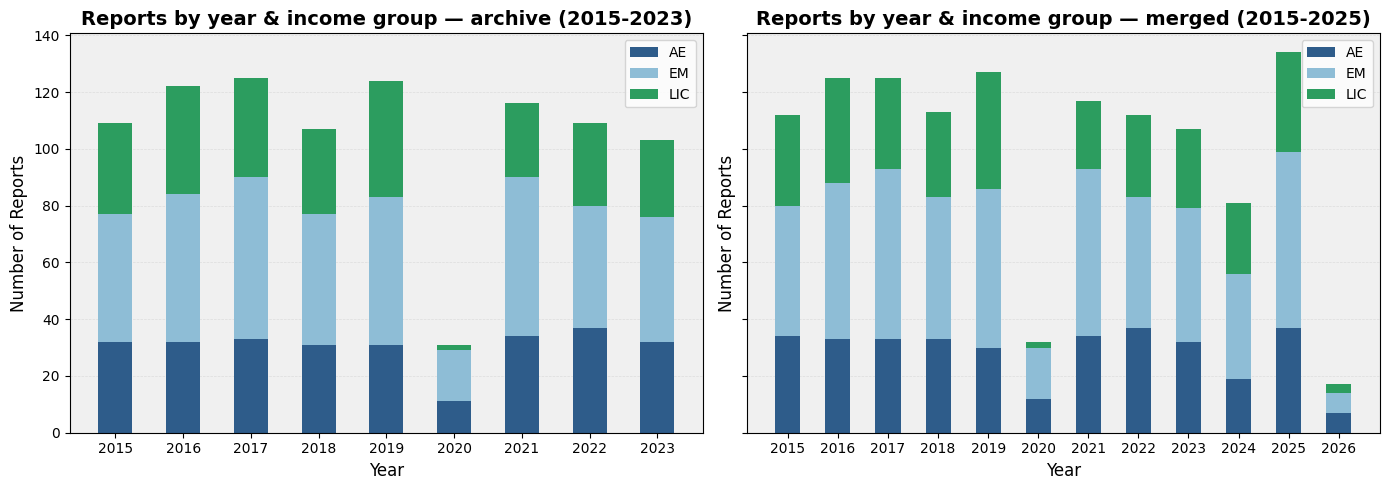

In [11]:
def _verified_mask(d):
    return d['mon_agreement_gpt_ft'].notna() | d['fis_agreement_gpt_ft'].notna()

print('=== Verified-doc counts ===')
for name, d in [('archive', df_arc), ('merged', df_new)]:
    mask = _verified_mask(d)
    print(f'  {name}: {mask.sum()} verified docs (of {len(d)} total)')

# Side-by-side stacked bars: year × income_group
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (name, d) in zip(axes, [('archive (2015-2023)', df_arc), ('merged (2015-2025)', df_new)]):
    sub = d[_verified_mask(d)].copy()
    sub = dvu.coerce_year_int(sub)
    counts = dvu.compute_year_group_counts(sub, year_col='year', group_col='income_group',
                                            group_order=['AE', 'EM', 'LIC'])
    dvu.plot_stacked_counts_by_year(counts, group_order=['AE', 'EM', 'LIC'],
                                     title=f'Reports by year & income group — {name}',
                                     ax=ax)
plt.tight_layout()
plt.show()

## 3 · Zero-shot general agreement (cross-sector)

Charts the `agreement_gpt` overall score and the five per-sector
`agreement_gpt_{Monetary|Fiscal|External|Financial|Real}` scores, side-by-side
archive vs merged.

**Caveat**: the 120 incremental rows were scored by `gpt-5.4-mini` with the new
strict-mode schema (step 07 of this pipeline); the 981 archive rows were scored
by the legacy `gpt-4o-2024-08-06` (`temp/reference_code/9.llm_general.py`).
Treat any merged-vs-archive shift in this section as a *combined* effect of
model upgrade + new sample period, not just sample expansion.

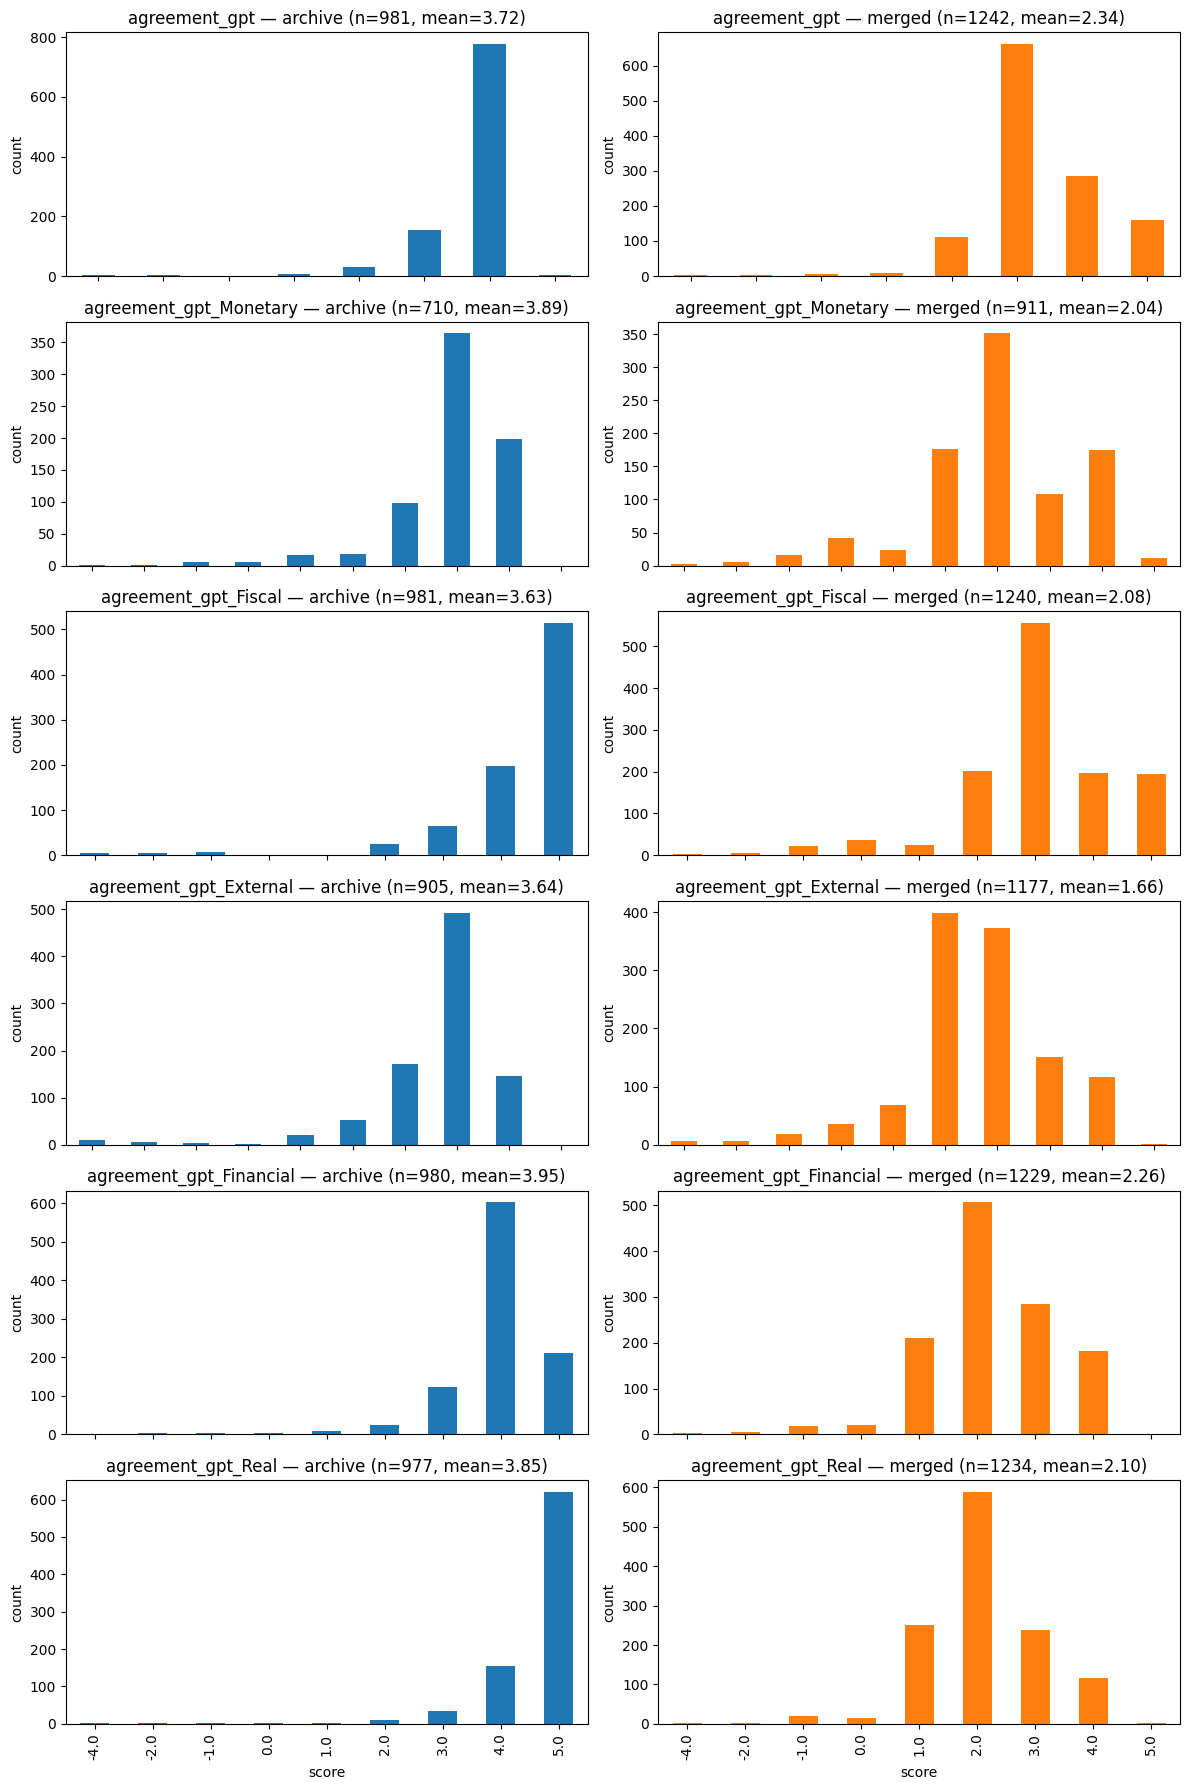

In [12]:
# --- Histograms of agreement_gpt and per-sector scores ---
SECTOR_SCORE_COLS = ['agreement_gpt'] + [f'agreement_gpt_{s}' for s in ('Monetary', 'Fiscal', 'External', 'Financial', 'Real')]

fig, axes = plt.subplots(len(SECTOR_SCORE_COLS), 2, figsize=(12, 3 * len(SECTOR_SCORE_COLS)), sharex='row')
for row, col in enumerate(SECTOR_SCORE_COLS):
    for col_idx, (name, d) in enumerate([('archive', df_arc), ('merged', df_new)]):
        ax = axes[row, col_idx]
        s = pd.to_numeric(d[col], errors='coerce').dropna()
        if len(s) == 0:
            ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center'); continue
        s.value_counts().sort_index().plot.bar(ax=ax, color=colors[col_idx])
        ax.set_title(f'{col} — {name} (n={len(s)}, mean={s.mean():.2f})')
        ax.set_xlabel('score')
        ax.set_ylabel('count')
plt.tight_layout()
plt.show()

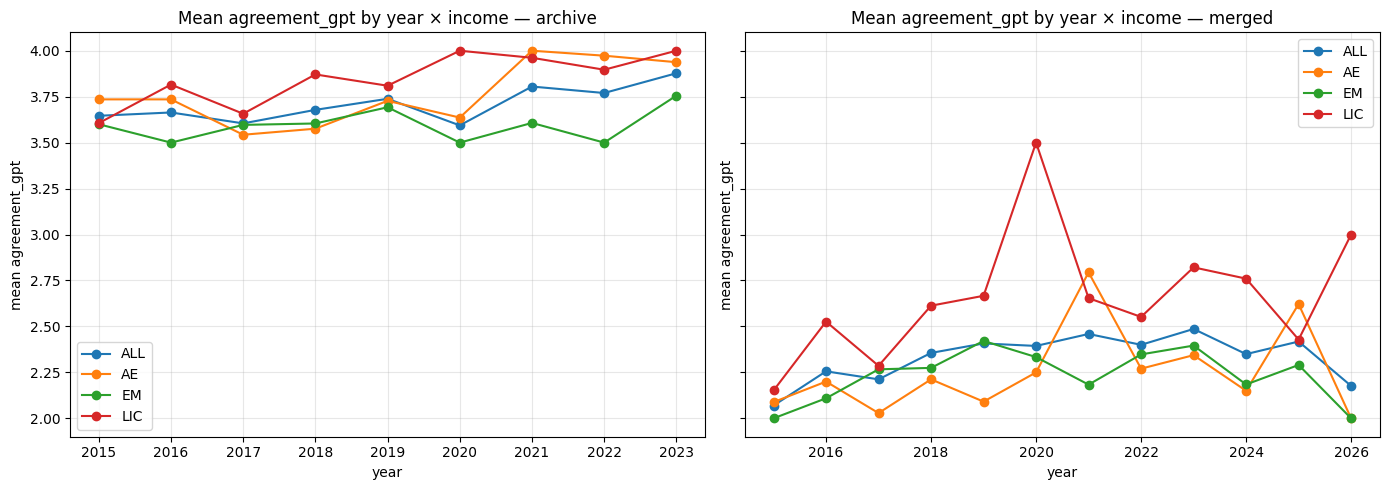

In [13]:
# --- Year-trend of mean agreement_gpt by income group ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (name, d) in zip(axes, [('archive', df_arc), ('merged', df_new)]):
    sub = d.copy()
    sub['agreement_gpt'] = pd.to_numeric(sub['agreement_gpt'], errors='coerce')
    sub = sub.dropna(subset=['agreement_gpt', 'year'])
    sub = dvu.coerce_year_int(sub)
    rows = []
    for grp in ('AE', 'EM', 'LIC', 'ALL'):
        if grp == 'ALL':
            g = sub
        else:
            g = sub[sub['income_group'] == grp]
        if len(g) == 0:
            continue
        means = g.groupby('year')['agreement_gpt'].mean()
        for yr, m in means.items():
            rows.append({'year': int(yr), 'group': grp, 'mean': m})
    if not rows:
        ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center'); continue
    long = pd.DataFrame(rows)
    for grp in ('ALL', 'AE', 'EM', 'LIC'):
        g = long[long['group'] == grp].sort_values('year')
        if len(g): ax.plot(g['year'], g['mean'], marker='o', label=grp)
    ax.set_title(f'Mean agreement_gpt by year × income — {name}')
    ax.set_xlabel('year'); ax.set_ylabel('mean agreement_gpt')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4 · Monetary stance & agreement

The reference notebook applies the same set of six per-sector analyses to
monetary (cells 37-53) and fiscal (cells 55-72). To stay aligned with that
while keeping each chart auditable, we define one chart-rendering function per
analysis. Each function takes `d_arc`, `d_new`, the sector prefix (`'mon'` or
`'fis'`), and the stance suffix (`'future'` for monetary, `'near_term'` for
fiscal), and renders that single chart side-by-side. Sections 4 and 5 then
just call the six functions in order.

The reference's `sector` loop assumes column names like
`stance_future_gpt_ft_staff`; the actual file has `mon_stance_future_gpt_ft_staff`.
Every function constructs column names by f-string.

In [14]:
# --- Sector-helper shared constants ---
# Normalise stance vocabulary: incremental rows have 'no change' and 'unclear'
# as separate labels; archive collapses to 'no change / unclear'. Map both
# variants to the collapsed label so all bars share the reference's 6-bucket
# vocabulary.
STANCE_ORDER_6 = ['tightening', 'tightening bias', 'no change / unclear', 'loosening bias', 'loosening']
STANCE_NORMALISE = {
    'no change': 'no change / unclear',
    'unclear': 'no change / unclear',
    'no change / unclear': 'no change / unclear',
}
IMF_VS_AUTH_ORDER_7 = ['significantly tighter', 'tighter', 'moderately tighter',
                        'same',
                        'moderately looser', 'looser', 'significantly looser']

STANCE_COLORS = {
    "tightening":          "#1F77B4",
    "tightening bias":     "#8ECAE6",
    "no change / unclear": "#DCEEF8",
    "loosening bias":      "#F4A582",
    "loosening":           "#B2182B",
}
STANCE_COLORS_5 = [STANCE_COLORS[k] for k in STANCE_ORDER_6]

IMF_VS_AUTH_COLORS_7 = ["#1F77B4", "#6BAED6", "#8ECAE6",
                         "#DCEEF8",
                         "#F4A582", "#D6604D", "#B2182B"]

def _norm_stance(series):
    return series.map(lambda v: STANCE_NORMALISE.get(v, v))

def _plot_stacked_share_by_year(d, *, col, title, color_palette, order,
                                  drop_irrelevant=True, figsize=(10, 4.5), ax=None):
    """Stacked-bar of value-counts share per year for `col`, restricted to `order`.

    If `ax` is None, creates its own figure and calls plt.show(). Otherwise
    draws into the provided Axes and returns (no show — caller manages the figure)."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    sub = d[d[col].notna()].copy()
    sub[col] = _norm_stance(sub[col])
    if drop_irrelevant:
        sub = sub[sub[col] != 'irrelevant']
    if sub.empty:
        ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center')
        ax.set_title(title)
        if standalone:
            plt.tight_layout(); plt.show()
        return ax
    sub = dvu.coerce_year_int(sub)
    ct = sub.groupby(['year', col]).size().unstack(fill_value=0)
    ct = ct.reindex(columns=order, fill_value=0)
    shares = ct.div(ct.sum(axis=1), axis=0).fillna(0)
    shares.plot.bar(stacked=True, color=color_palette, ax=ax, width=0.85)
    ax.set_title(title)
    ax.set_xlabel(''); ax.set_ylabel('share')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), ncol=1, fontsize=8)
    if standalone:
        plt.tight_layout(); plt.show()
    return ax

In [15]:
# --- Chart 1: Agreement value-counts bar ---
# Reference: cells around 42 (monetary). Plots the binary
# {mon,fis}_agreement_gpt_ft distribution as a standalone figure.

def plot_agreement_value_counts(d, *, sector_prefix, label, ax=None):
    agree_col = f'{sector_prefix}_agreement_gpt_ft'
    sub = d[d[agree_col].notna()]
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 4))
    if sub.empty:
        ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center')
    else:
        sub[agree_col].value_counts().plot.bar(ax=ax, color=colors[1])
    ax.set_title(f'{agree_col} — {label} (n={len(sub)})')
    if standalone:
        plt.tight_layout(); plt.show()

In [16]:
# --- Chart 2: "No disagreement" proportion by year × income group ---
# Reference: cells 43 (monetary) and 62 (fiscal) both use
# {sector}_agreement_general_gpt_ft (the COMBINED measure that folds in
# stance + agreement + area-level disagreement). NOT
# {sector}_agreement_gpt_ft (raw agreement only). Using the raw column
# overstates "no disagreement", especially for fiscal where the two diverge
# by ~12pp.

def plot_no_disagreement_trend(d, *, sector_prefix, label, ax=None):
    general_col = f'{sector_prefix}_agreement_general_gpt_ft'
    sub = d[d[general_col].notna()].copy()
    sub = dvu.coerce_year_int(sub)
    sub['no_disagreement'] = (pd.to_numeric(sub[general_col], errors='coerce') == 1.0)
    y0, y1 = int(sub['year'].min()), int(sub['year'].max())
    sub = dvu.filter_year_range(sub, start_year=y0, end_year=y1)
    props = dvu.compute_no_disagreement_proportions_by_year(sub, group_col='income_group', groups=INCOME_GROUPS)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))
    if props.empty:
        ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center')
    else:
        dvu.plot_group_lines_by_year(props, groups=INCOME_GROUPS,
            title=f'"No disagreement" % — {sector_prefix} — {label}',
            ylim=(0, 105),
            ax=ax)
    if standalone:
        plt.tight_layout(); plt.show()

In [17]:
# --- Chart 3: Top disagreement-area frequencies + % of reports line chart ---
# Uses LLM-based classification (with persistent cache) to map raw disagreement
# area labels to higher-level categories. See
# post_estimate_analysis/classify_disagreement_areas.py.


def _extract_area_list(val):
    """Parse a disagreement-areas cell value into a flat list of strings."""
    if isinstance(val, list):
        return [v for v in val if isinstance(v, str)]
    if isinstance(val, str):
        if val.startswith('['):
            try:
                parsed = ast.literal_eval(val)
                if isinstance(parsed, list):
                    return [str(v) for v in parsed]
            except (ValueError, SyntaxError):
                pass
        return [val]
    return []


def _build_general_areas(d, sector_prefix):
    """Build general disagreement areas by augmenting raw areas with stance-derived entries.

    For monetary: adds 'current policy stance' and 'future policy direction'
    based on stance agreement columns (mirrors reference notebook cell 40).
    For fiscal: uses the pre-built fis_disagreement_areas_general_gpt_ft column.
    Returns a Series of lists aligned with d.
    """
    dis_col = f'{sector_prefix}_disagreement_areas_gpt_ft'

    if sector_prefix == 'fis':
        gen_col = 'fis_disagreement_areas_general_gpt_ft'
        if gen_col in d.columns:
            return d[gen_col].apply(_extract_area_list)
        return d[dis_col].apply(_extract_area_list) if dis_col in d.columns else pd.Series([[]] * len(d), index=d.index)

    raw_areas = d[dis_col].apply(_extract_area_list) if dis_col in d.columns else pd.Series([[]] * len(d), index=d.index)
    stance_current_col = f'{sector_prefix}_agreement_stance_current_gpt_ft'
    stance_future_col = f'{sector_prefix}_agreement_stance_future_gpt_ft'

    result = []
    for idx in d.index:
        areas = list(raw_areas.loc[idx])
        if stance_current_col in d.columns:
            sc = d.at[idx, stance_current_col]
            if sc == 'disagreement exists' and 'current policy stance' not in areas:
                areas.append('current policy stance')
        if stance_future_col in d.columns:
            sf = d.at[idx, stance_future_col]
            if sf == 'disagreement exists' and 'future policy direction' not in areas:
                areas.append('future policy direction')
        result.append(areas)
    return pd.Series(result, index=d.index)


def _classify_general_areas(d, sector_prefix):
    """Extract general areas from d and classify them via LLM cache.

    Returns (all_areas, area_to_category, general_areas_series) or None if empty.
    """
    dis_col = f'{sector_prefix}_disagreement_areas_gpt_ft'
    sector_name = PREFIX_TO_SECTOR.get(sector_prefix, sector_prefix.title())
    if dis_col not in d.columns:
        return None
    sub = d[d[dis_col].notna()].copy()
    if sub.empty:
        return None
    general_areas = _build_general_areas(sub, sector_prefix)
    all_areas = list(itertools.chain.from_iterable(general_areas))
    if not all_areas:
        return None
    area_to_category = classify_areas_batch(all_areas, sector=sector_name)
    return all_areas, area_to_category, general_areas, sub


def print_top_disagreement_areas(d, *, sector_prefix, label, ax=None):
    dis_col = f'{sector_prefix}_disagreement_areas_gpt_ft'
    sector_name = PREFIX_TO_SECTOR.get(sector_prefix, sector_prefix.title())

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))

    result = _classify_general_areas(d, sector_prefix)
    if result is None:
        ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center')
        ax.set_title(f'Disagreement Areas — {sector_name} — {label}')
        if standalone:
            plt.tight_layout(); plt.show()
        return

    all_areas, area_to_category, _, _ = result
    categories = pd.Series(all_areas).apply(lambda x: area_to_category.get(x.lower().strip(), 'Other'))
    top = categories.value_counts()

    top.plot.barh(ax=ax, color=[colors_cate[i % len(colors_cate)] for i in range(len(top))])
    ax.set_title(f'Disagreement Areas — {sector_name} — {label} (n={len(all_areas)})')
    ax.set_xlabel('count')
    ax.invert_yaxis()

    if standalone:
        plt.tight_layout(); plt.show()


def plot_disagreement_area_pct(d, *, sector_prefix, label, ax=None):
    """Line chart: % of reports with disagreement in each category, by year."""
    dis_col = f'{sector_prefix}_disagreement_areas_gpt_ft'
    sector_name = PREFIX_TO_SECTOR.get(sector_prefix, sector_prefix.title())

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))

    result = _classify_general_areas(d, sector_prefix)
    if result is None:
        ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center')
        ax.set_title(f'% of Reports with Disagreement by Area: {sector_name} — {label}')
        if standalone:
            plt.tight_layout(); plt.show()
        return

    all_areas, area_to_category, general_areas, sub = result
    sub = dvu.coerce_year_int(sub)

    # Classify each row's areas into categories
    classified = general_areas.apply(
        lambda areas: [area_to_category.get(a.lower().strip(), 'Other') for a in areas]
    )

    # Explode: one row per (year, category)
    rows = []
    for i, idx in enumerate(sub.index):
        yr = sub.at[idx, 'year']
        for cat in classified.iloc[i]:
            rows.append({'year': yr, 'category': cat})
    if not rows:
        ax.text(0.5, 0.5, '(no classified areas)', transform=ax.transAxes, ha='center')
        if standalone:
            plt.tight_layout(); plt.show()
        return

    df_temp = pd.DataFrame(rows)
    reports_per_year = sub.groupby('year').size()

    cat_counts = df_temp.groupby(['year', 'category']).size().reset_index(name='count')
    pivot = cat_counts.pivot_table(index='year', columns='category', values='count', fill_value=0)
    pct = (pivot.T / reports_per_year).T.fillna(0) * 100

    col_order = pct.sum().sort_values(ascending=False).index
    pct = pct[col_order]

    pct.plot(ax=ax, marker='o', color=[colors_cate[i % len(colors_cate)] for i in range(len(pct.columns))])
    ax.set_title(f'% of Reports with Disagreement by Area: {sector_name} — {label}')
    ax.set_xlabel('')
    ax.set_ylabel('% of reports')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), ncol=1, fontsize=8)
    ax.grid(True, alpha=0.3)

    if standalone:
        plt.tight_layout(); plt.show()

In [18]:
# --- Chart 4: Staff's policy advice by year (stacked bars, 5 stance buckets) ---
# Reference cells 52 (monetary), 71 (fiscal)
def plot_staff_policy_advice(d, *, sector_prefix, stance_col, label, ax=None):
    stance_staff = f'{sector_prefix}_stance_{stance_col}_gpt_ft_staff'
    _plot_stacked_share_by_year(d, col=stance_staff,
        title=f"Staff's {sector_prefix.upper()} Policy Advice by Year — {label}",
        color_palette=STANCE_COLORS_5, order=STANCE_ORDER_6, ax=ax)

In [19]:
# --- Chart 5: Authorities' policy direction by year (stacked bars, 5 stance buckets) ---
# Reference cells 51 (monetary), 69 (fiscal)
def plot_authorities_policy_direction(d, *, sector_prefix, stance_col, label, ax=None):
    stance_buff = f'{sector_prefix}_stance_{stance_col}_gpt_ft_buff'
    _plot_stacked_share_by_year(d, col=stance_buff,
        title=f"Authorities' {sector_prefix.upper()} Policy Direction by Year — {label}",
        color_palette=STANCE_COLORS_5, order=STANCE_ORDER_6, ax=ax)

In [20]:
# --- Chart 6: IMF advice compared to authorities (stacked bars, 7 buckets) ---
# Reference cells 48 (monetary), 68 (fiscal)
def plot_imf_vs_authorities(d, *, sector_prefix, stance_col, label, ax=None):
    cate2_col = f'{sector_prefix}_agreement_stance_{stance_col}_gpt_ft_cate2'
    if cate2_col not in d.columns:
        print(f'  (skipping IMF-vs-authority: {cate2_col} not present)'); return
    _plot_stacked_share_by_year(d, col=cate2_col,
        title=f"IMF Advice vs Authorities' {sector_prefix.upper()} Direction — {label}",
        color_palette=IMF_VS_AUTH_COLORS_7, order=IMF_VS_AUTH_ORDER_7, ax=ax)

In [21]:
# --- Sector dispatcher: merged headline + archive↔merged side-by-side comparison ---
# For each of the seven charts we render:
#   1. the MERGED version on its own (publication-candidate)
#   2. a side-by-side ARCHIVE vs MERGED grid for visual diff
# Both are produced via the single-dataset chart functions defined above —
# the side-by-side just calls them twice through a small subplot wrapper.

def _side_by_side(d_arc, d_new, chart_fn, *, chart_kwargs):
    """Render chart_fn(d_arc, …) and chart_fn(d_new, …) as (1, 2) subplots.

    Each chart function honours an optional `ax` kwarg — when passed, it
    draws into that Axes and doesn't call plt.show itself, so we own the
    figure lifecycle here."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    chart_fn(d_arc, label='archive', ax=axes[0], **chart_kwargs)
    chart_fn(d_new, label='merged',  ax=axes[1], **chart_kwargs)
    fig.tight_layout()
    plt.show()


def run_sector_analysis(d_arc, d_new, *, sector_prefix, stance_col):
    """For each chart: render merged solo, then archive↔merged side-by-side."""
    chart_steps = [
        ('Agreement value counts',
            plot_agreement_value_counts,
            dict(sector_prefix=sector_prefix)),
        ('"No disagreement" % trend',
            plot_no_disagreement_trend,
            dict(sector_prefix=sector_prefix)),
        ('Disagreement areas (bar)',
            print_top_disagreement_areas,
            dict(sector_prefix=sector_prefix)),
        ('% of Reports with Disagreement by Area',
            plot_disagreement_area_pct,
            dict(sector_prefix=sector_prefix)),
        ("Staff's policy advice",
            plot_staff_policy_advice,
            dict(sector_prefix=sector_prefix, stance_col=stance_col)),
        ("Authorities' policy direction",
            plot_authorities_policy_direction,
            dict(sector_prefix=sector_prefix, stance_col=stance_col)),
        ('IMF advice vs authorities',
            plot_imf_vs_authorities,
            dict(sector_prefix=sector_prefix, stance_col=stance_col)),
    ]
    print(f'\n========== {sector_prefix.upper()} sector — {stance_col} ==========')
    for chart_name, chart_fn, chart_kwargs in chart_steps:
        print(f'\n--- {chart_name} (merged) ---')
        chart_fn(d_new, label='merged', **chart_kwargs)
        print(f'\n--- {chart_name} (archive vs merged) ---')
        _side_by_side(d_arc, d_new, chart_fn, chart_kwargs=chart_kwargs)


========== MON sector — future ==========

--- Agreement value counts (merged) ---


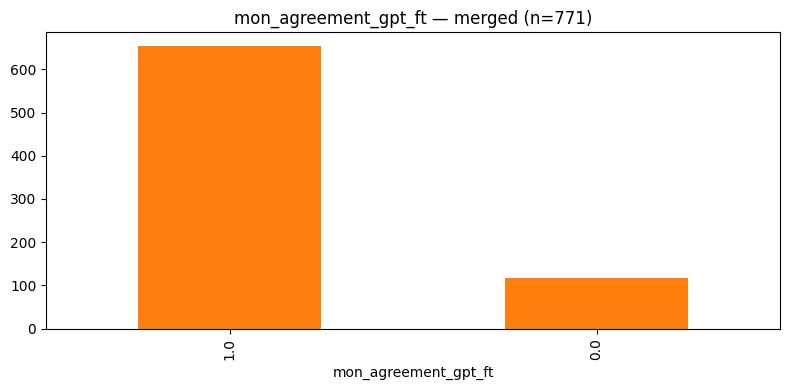


--- Agreement value counts (archive vs merged) ---


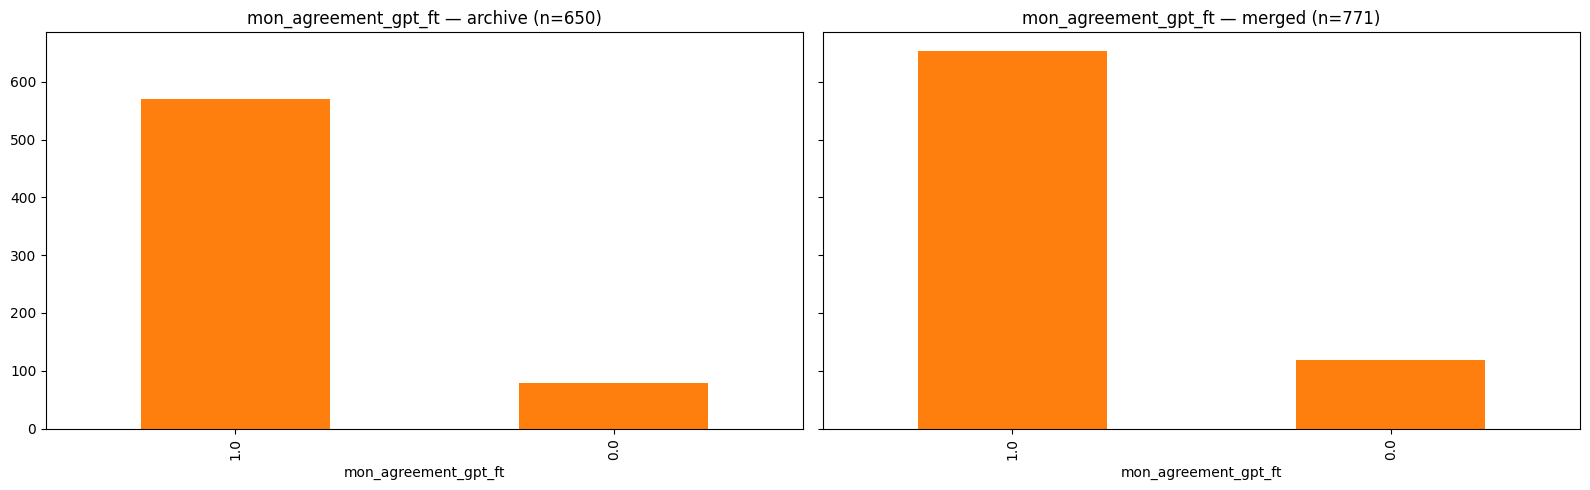


--- "No disagreement" % trend (merged) ---


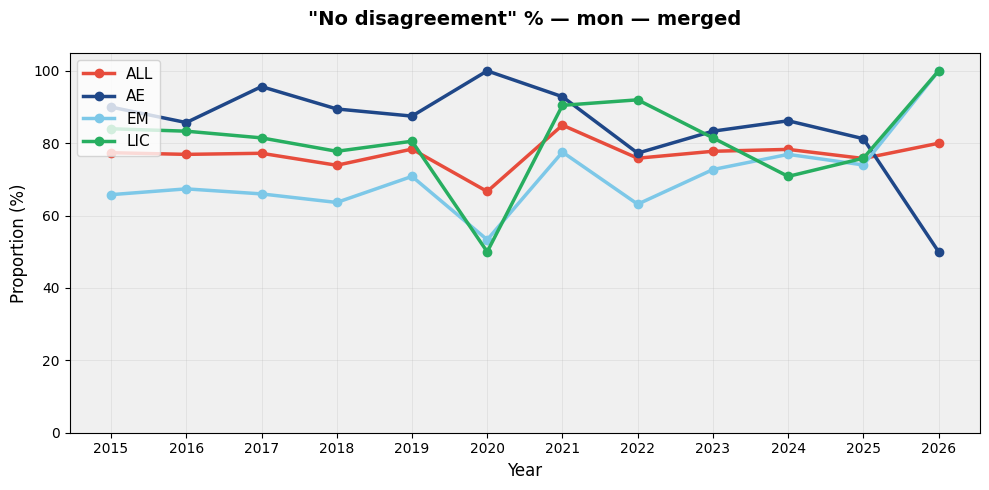


--- "No disagreement" % trend (archive vs merged) ---


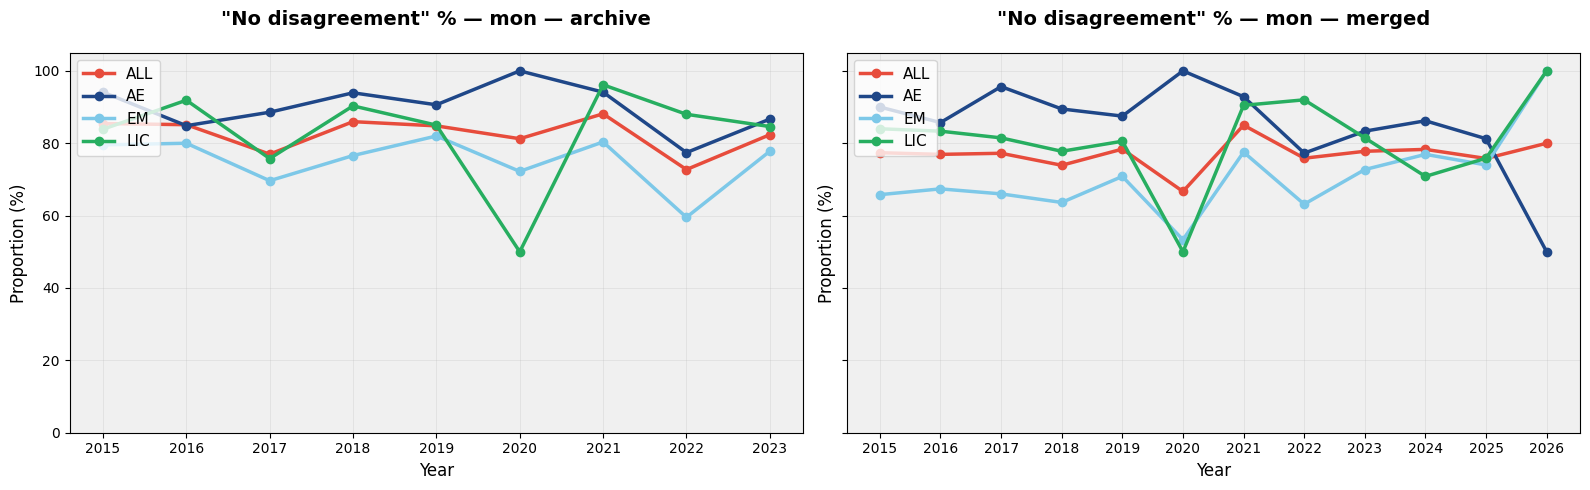


--- Disagreement areas (bar) (merged) ---
  [classify] Monetary: 1 new labels to classify (16 cached)


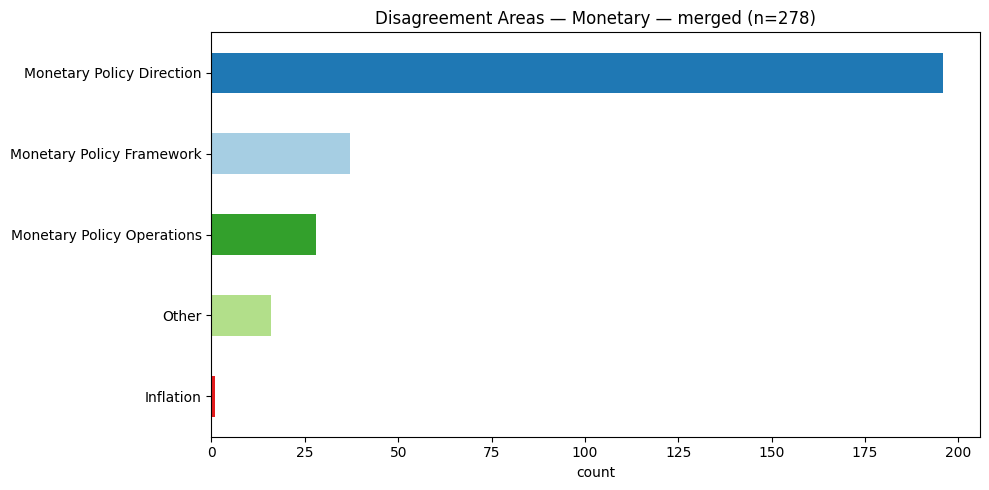


--- Disagreement areas (bar) (archive vs merged) ---


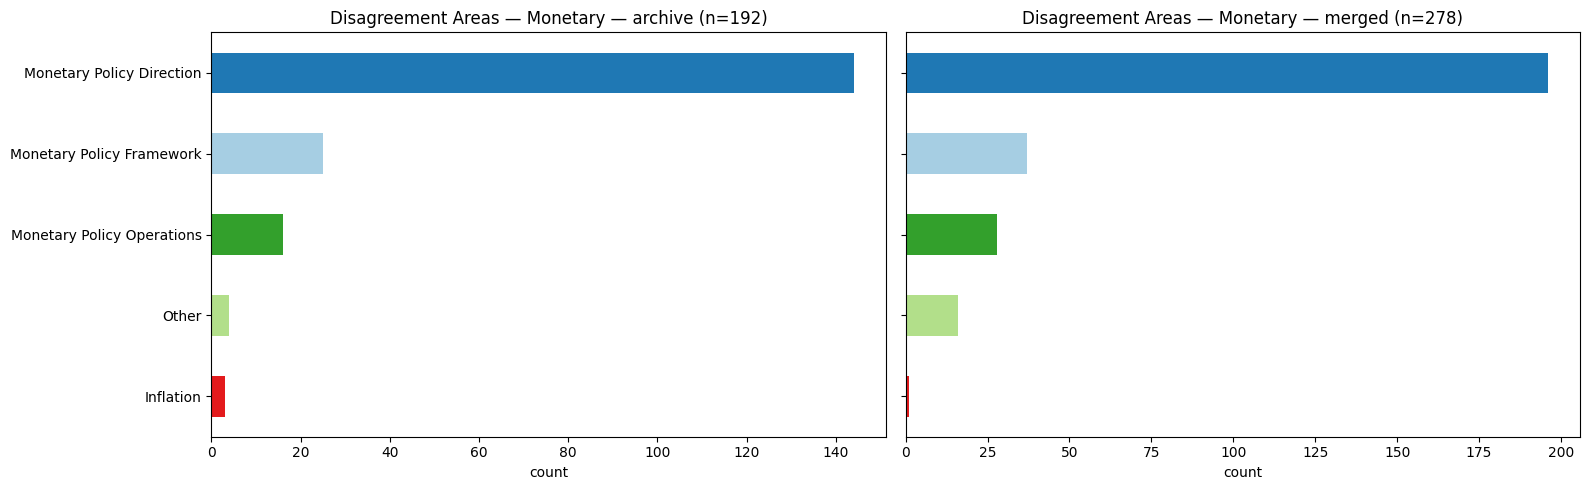


--- % of Reports with Disagreement by Area (merged) ---


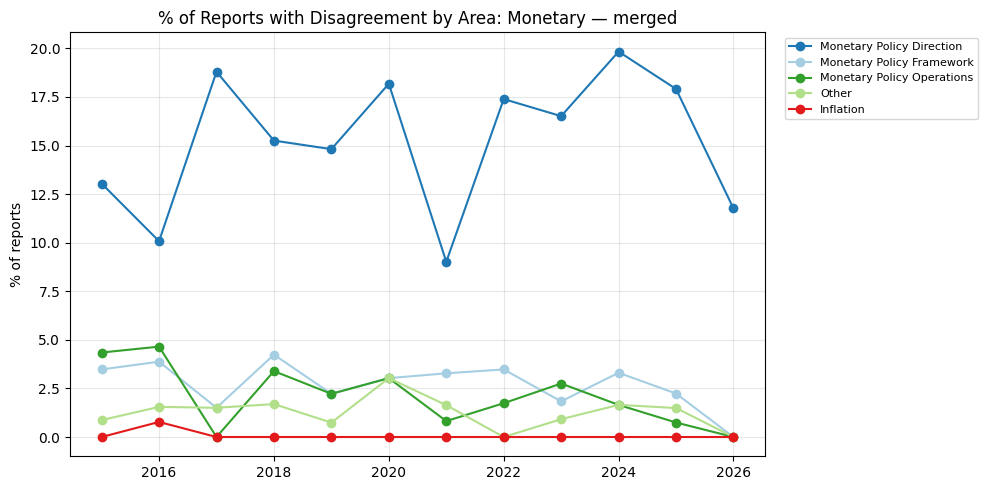


--- % of Reports with Disagreement by Area (archive vs merged) ---


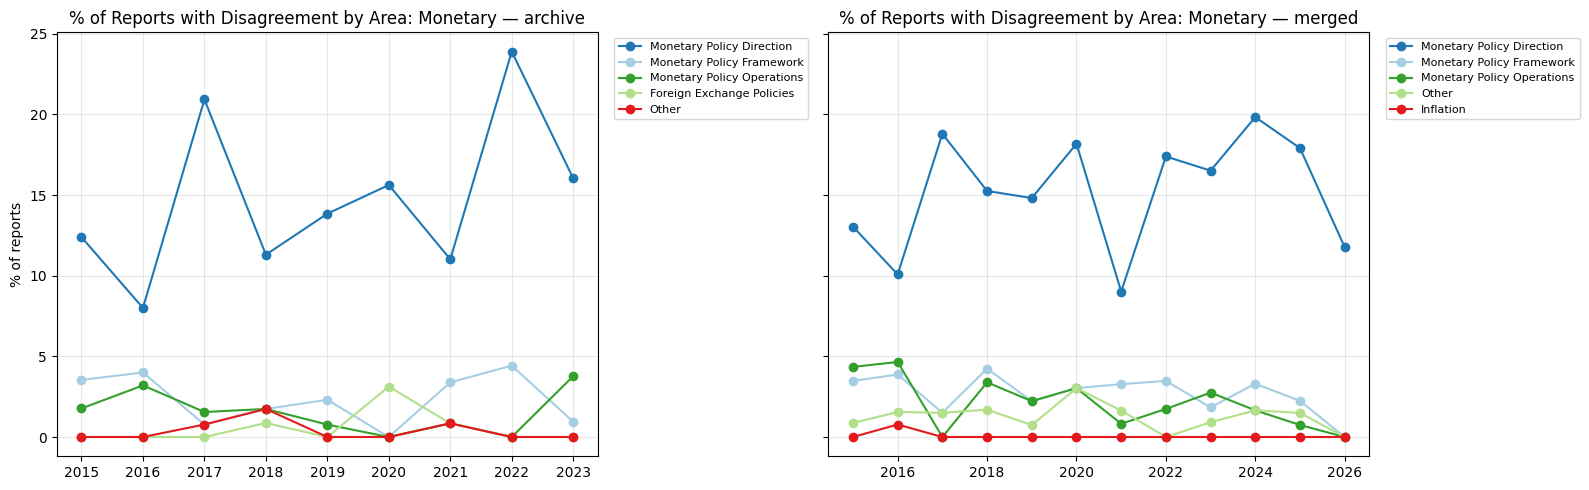


--- Staff's policy advice (merged) ---


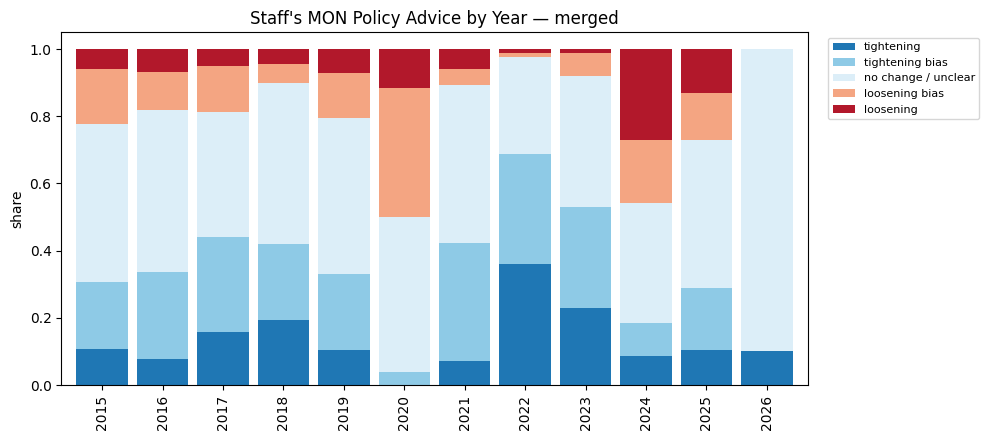


--- Staff's policy advice (archive vs merged) ---


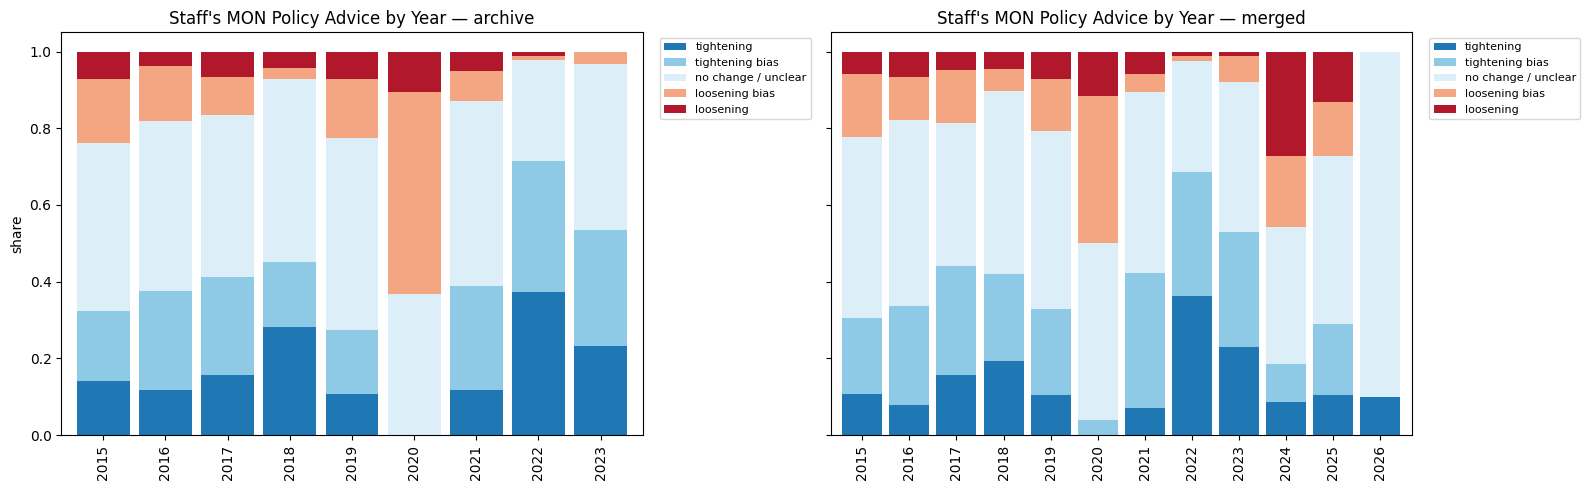


--- Authorities' policy direction (merged) ---


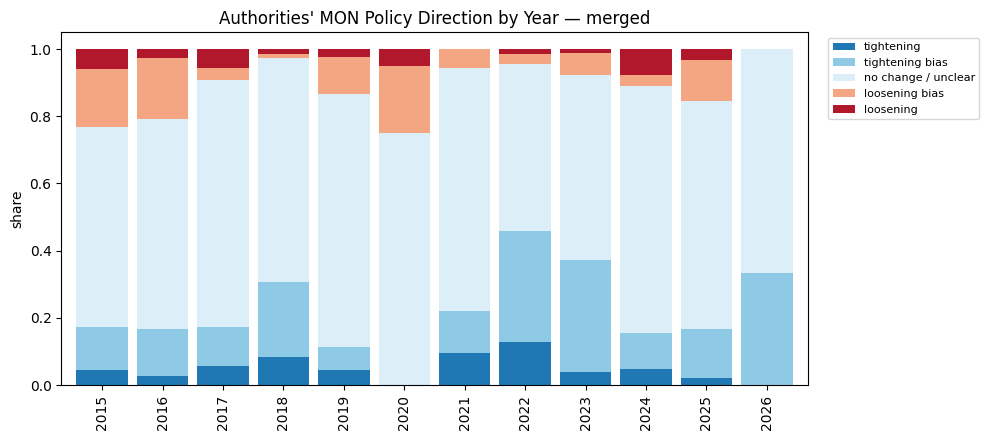


--- Authorities' policy direction (archive vs merged) ---


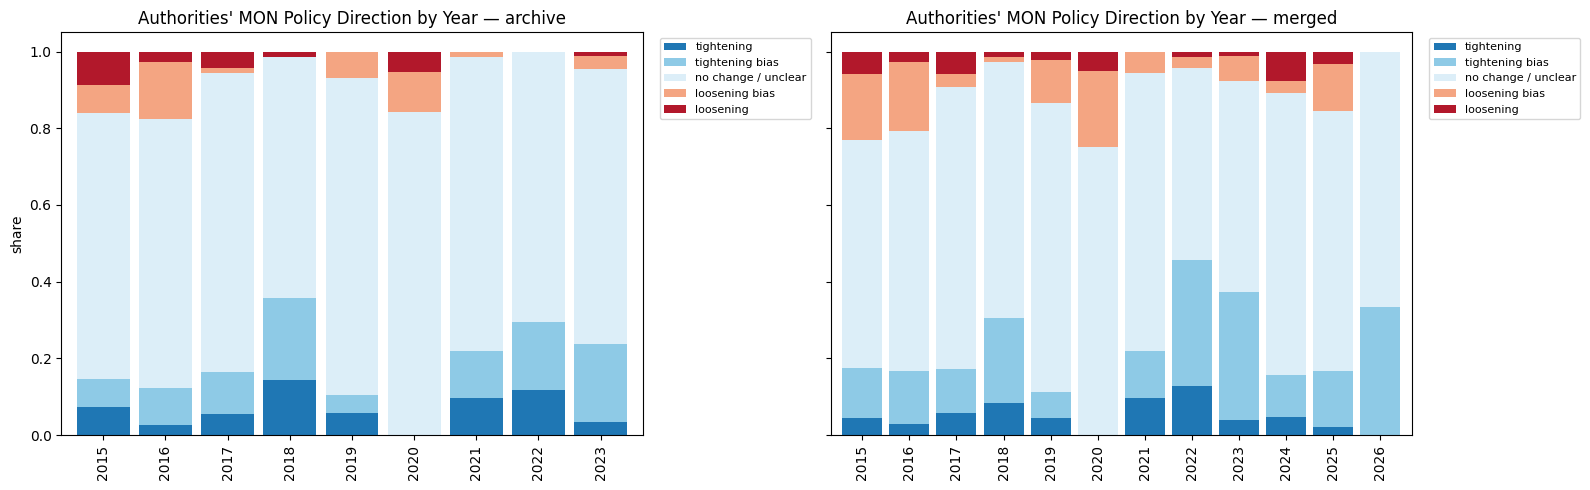


--- IMF advice vs authorities (merged) ---


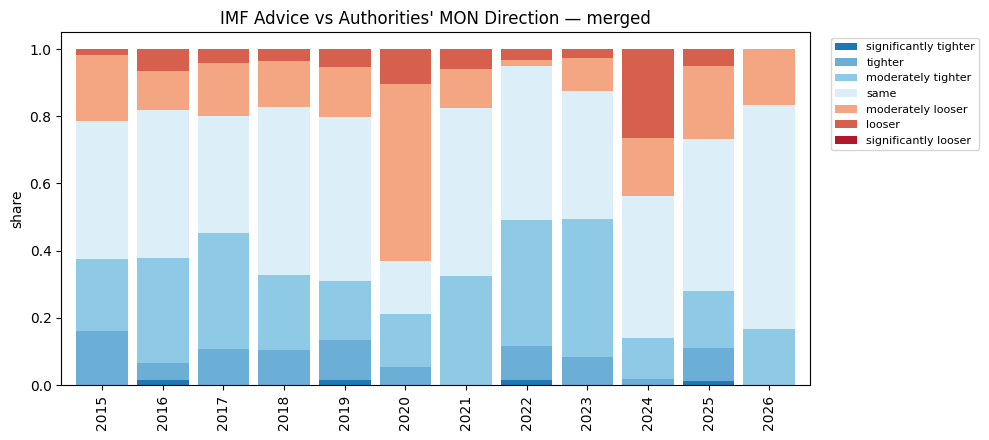


--- IMF advice vs authorities (archive vs merged) ---


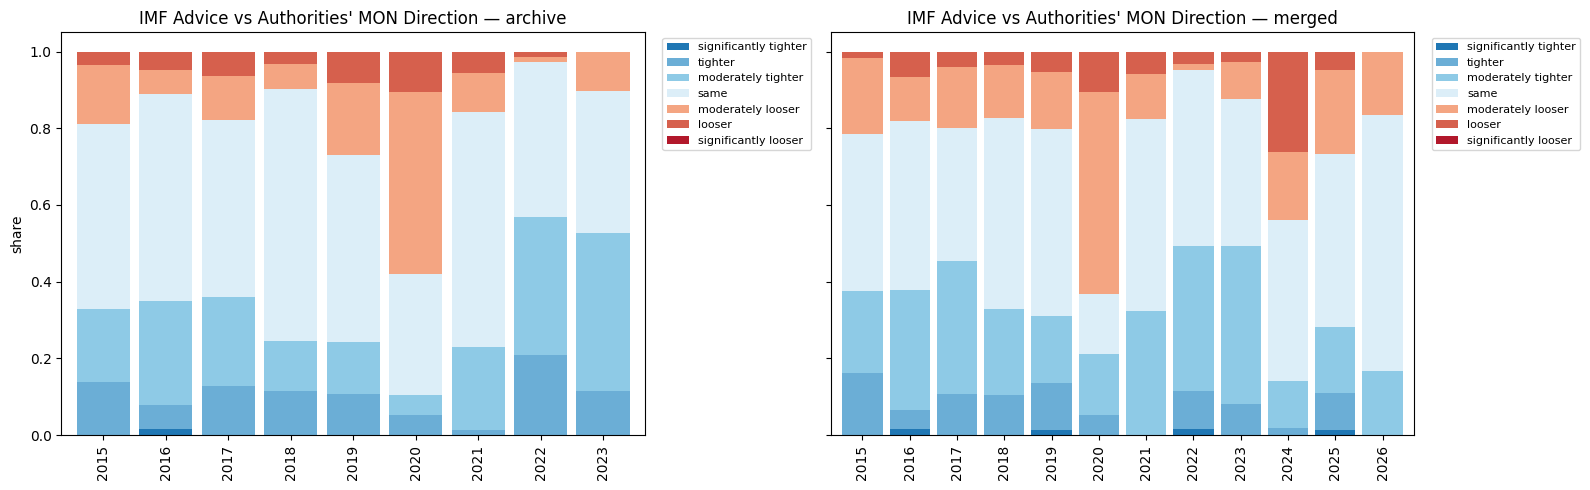

In [22]:
# --- Monetary sector ---
run_sector_analysis(df_arc, df_new, sector_prefix='mon', stance_col='future')

## 5 · Fiscal stance & agreement

Same six chart helpers as Section 4, called with `sector_prefix='fis'` and
`stance_col='near_term'`. The reference's CAPB macro chart (cell 70) is
skipped — `capb_ae` / `capb_emde` are not in `df_fin_reg_core`.


========== FIS sector — near_term ==========

--- Agreement value counts (merged) ---


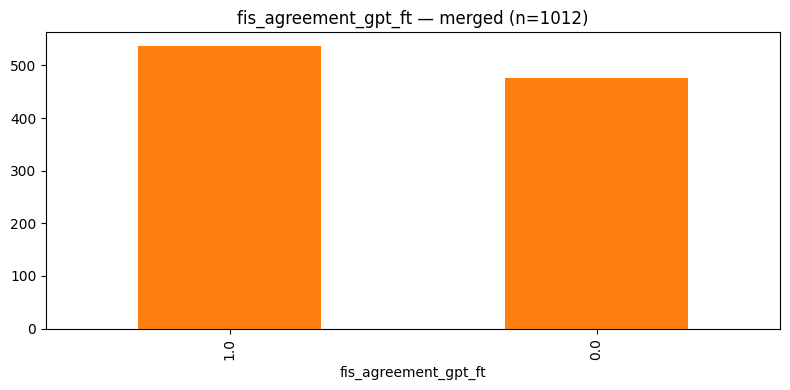


--- Agreement value counts (archive vs merged) ---


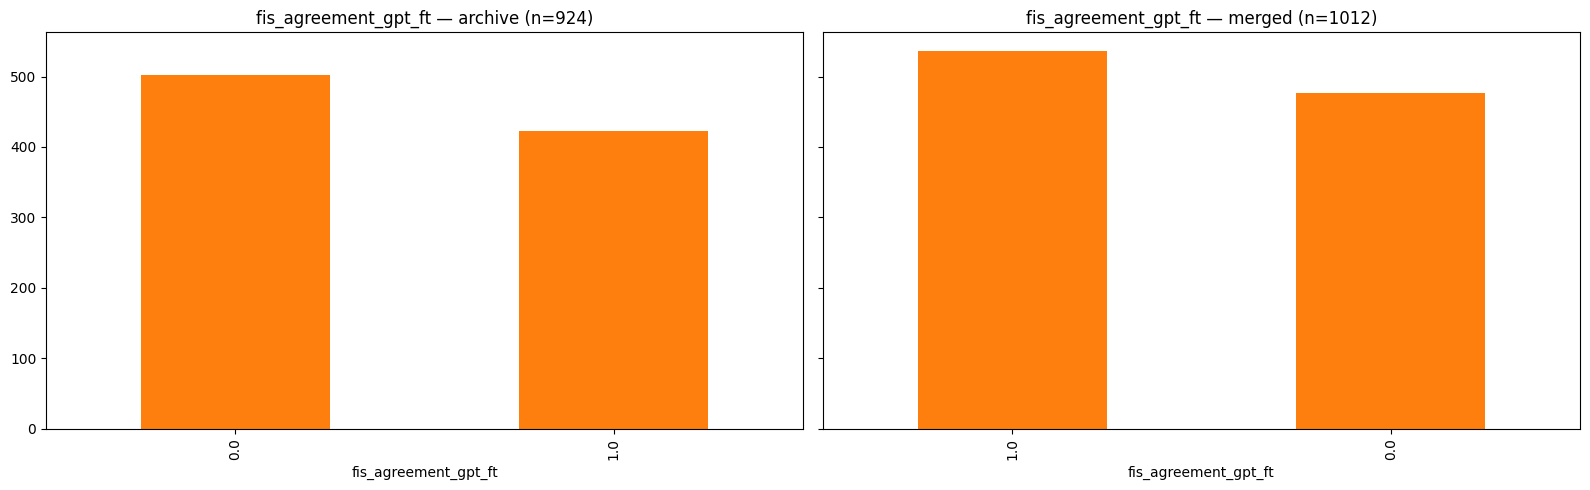


--- "No disagreement" % trend (merged) ---


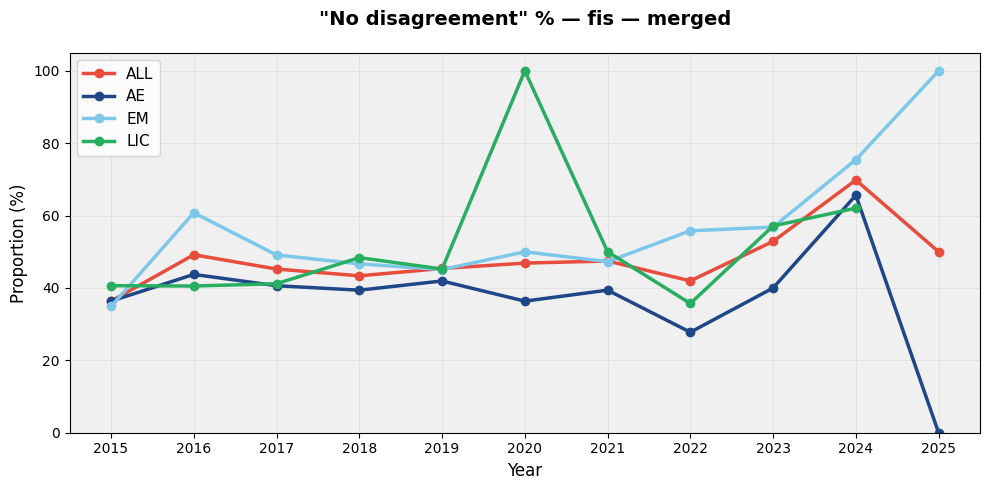


--- "No disagreement" % trend (archive vs merged) ---


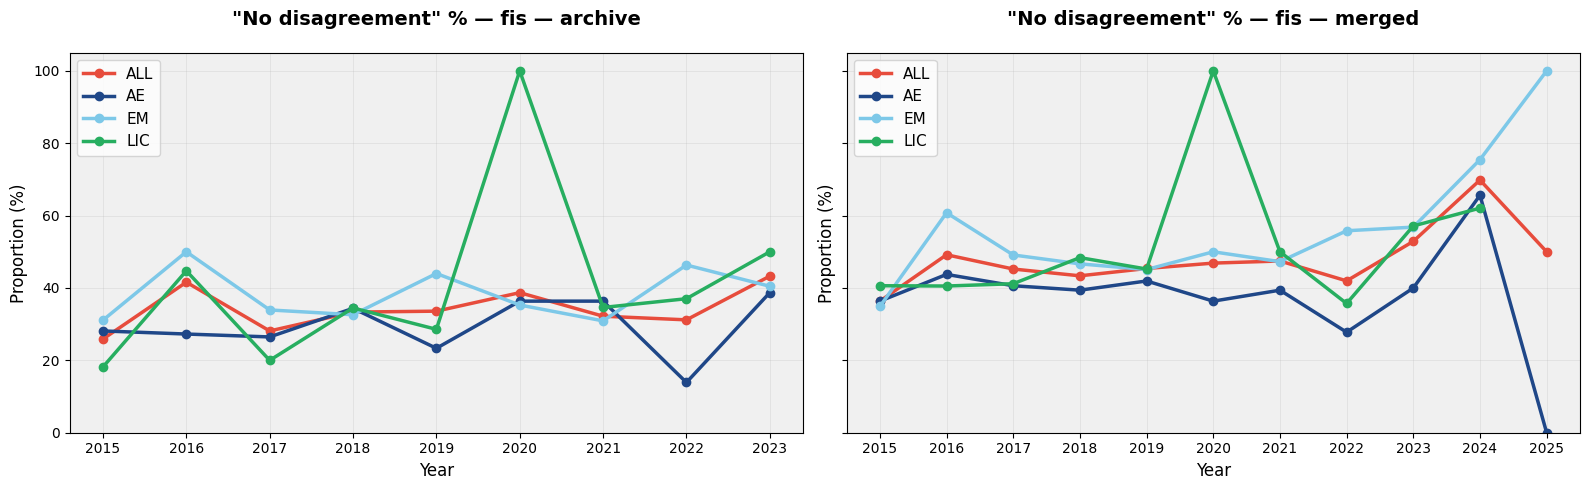


--- Disagreement areas (bar) (merged) ---


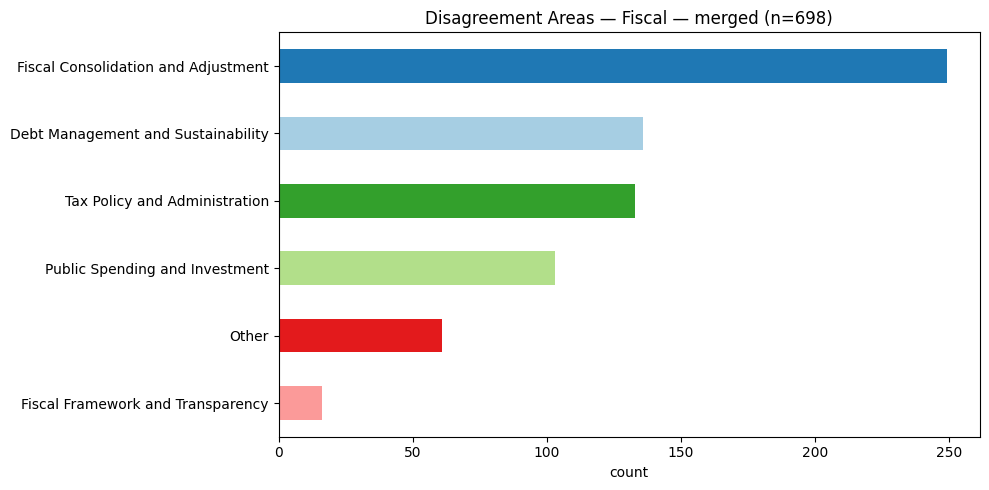


--- Disagreement areas (bar) (archive vs merged) ---


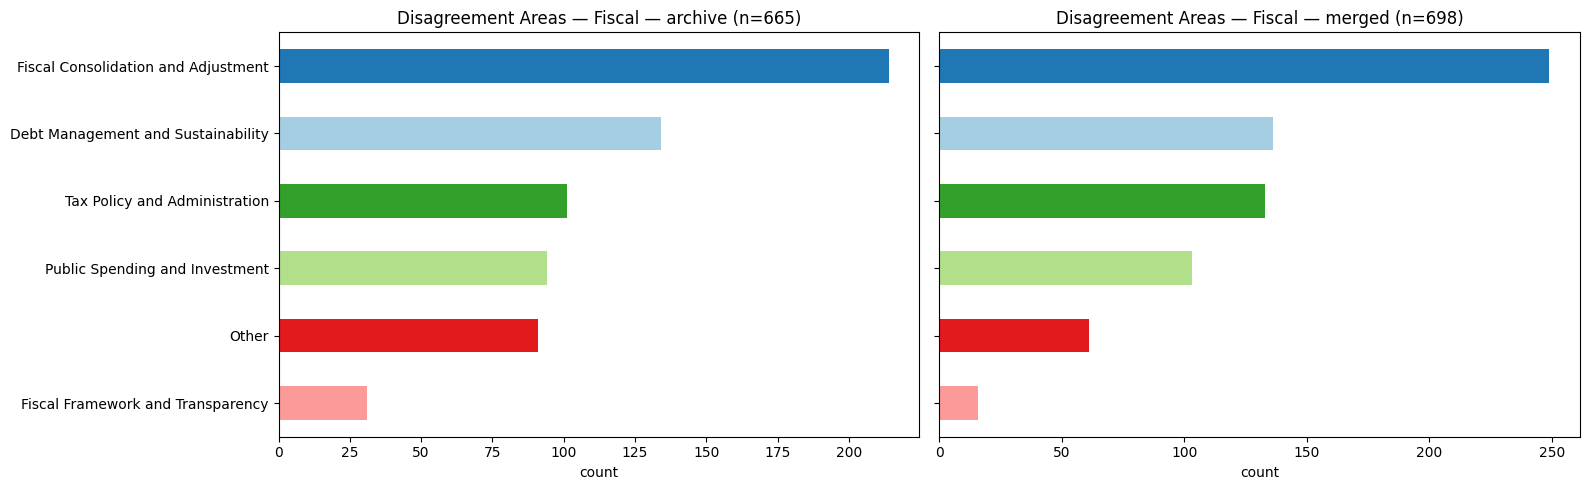


--- % of Reports with Disagreement by Area (merged) ---


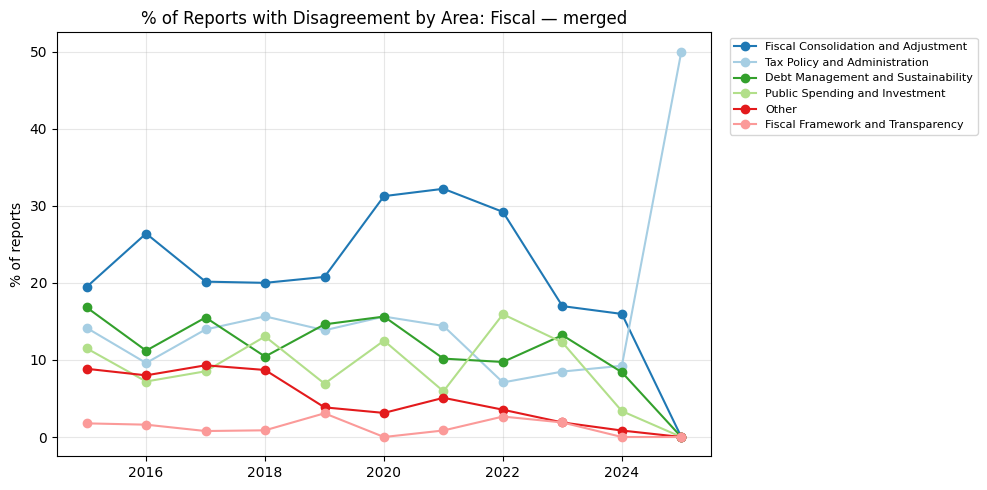


--- % of Reports with Disagreement by Area (archive vs merged) ---


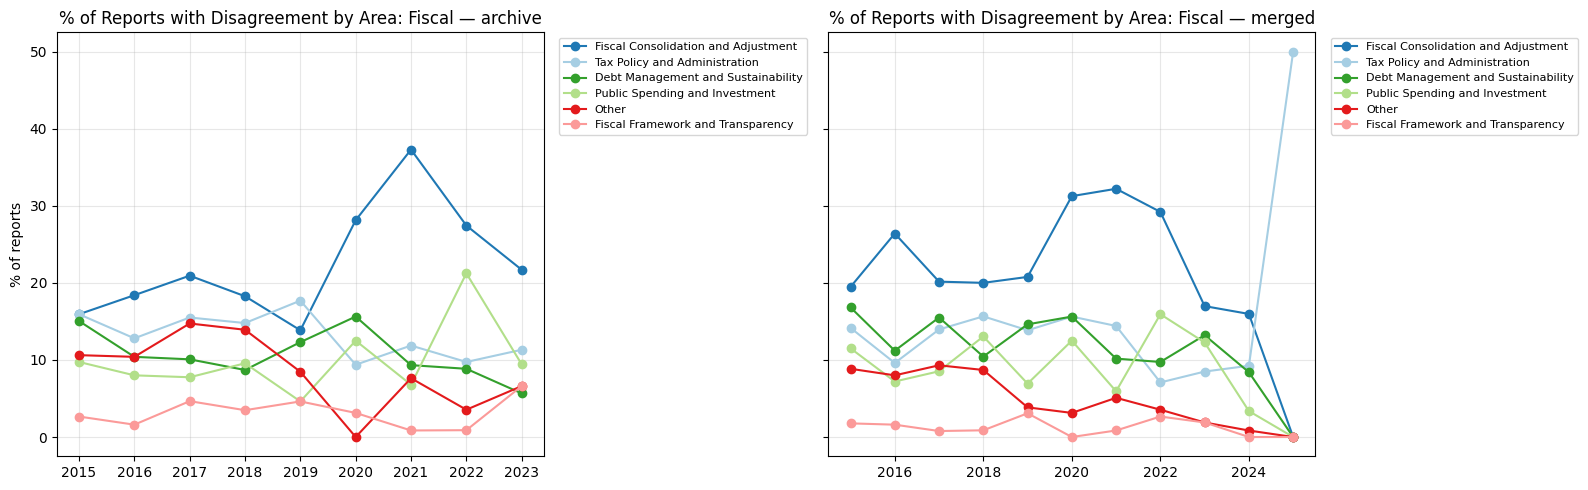


--- Staff's policy advice (merged) ---


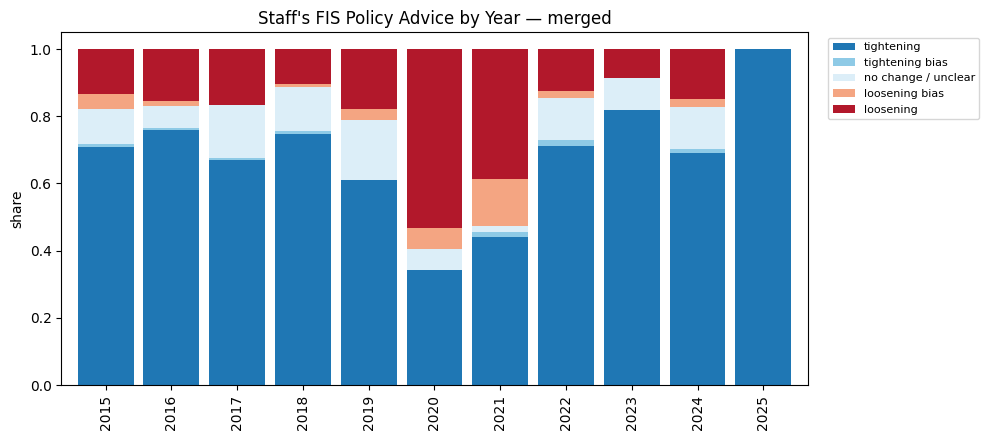


--- Staff's policy advice (archive vs merged) ---


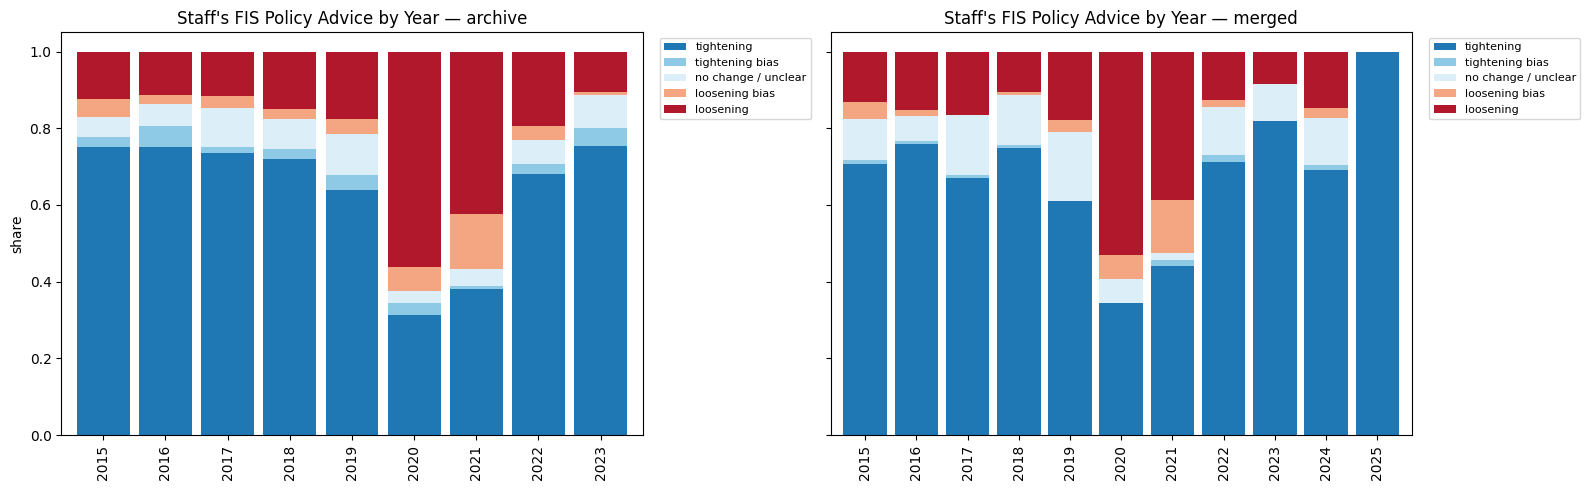


--- Authorities' policy direction (merged) ---


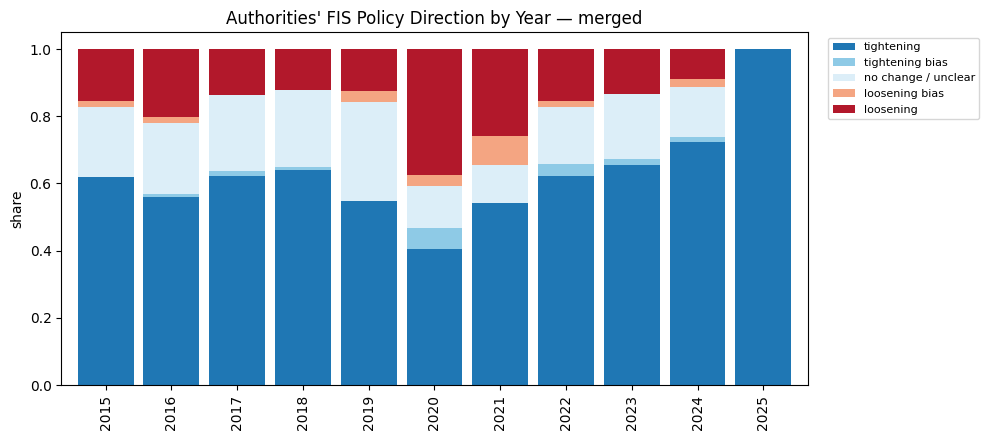


--- Authorities' policy direction (archive vs merged) ---


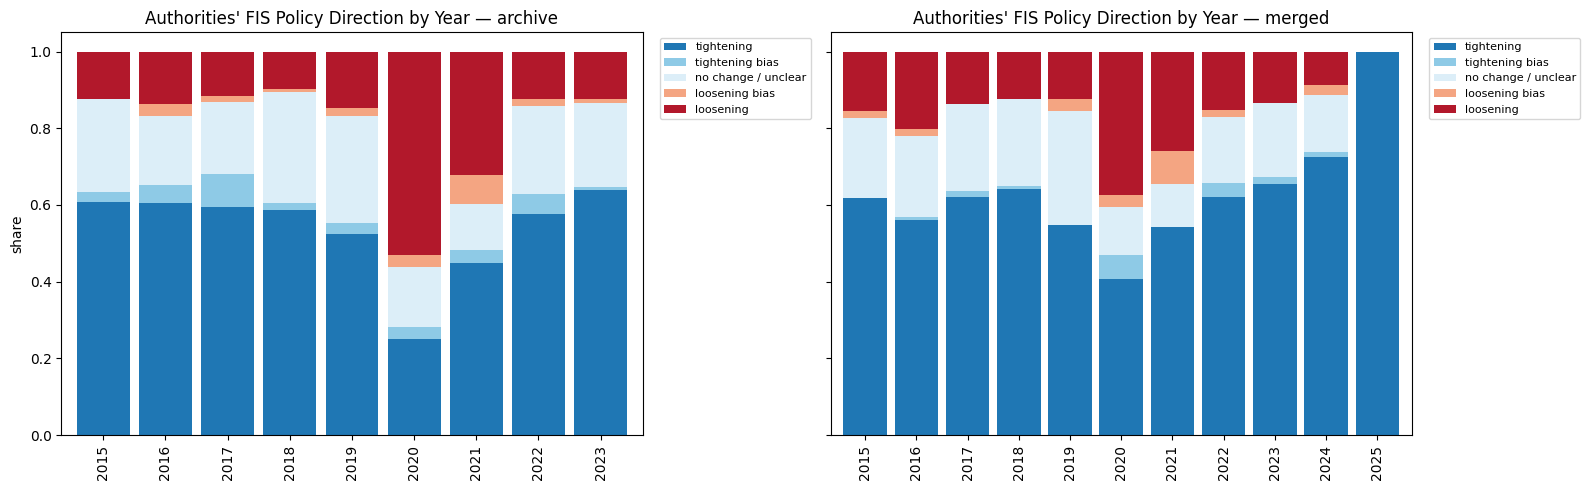


--- IMF advice vs authorities (merged) ---


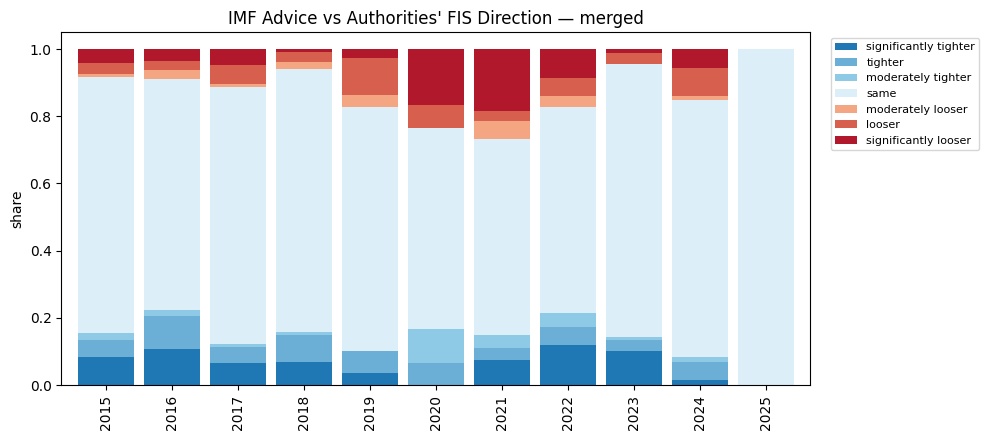


--- IMF advice vs authorities (archive vs merged) ---


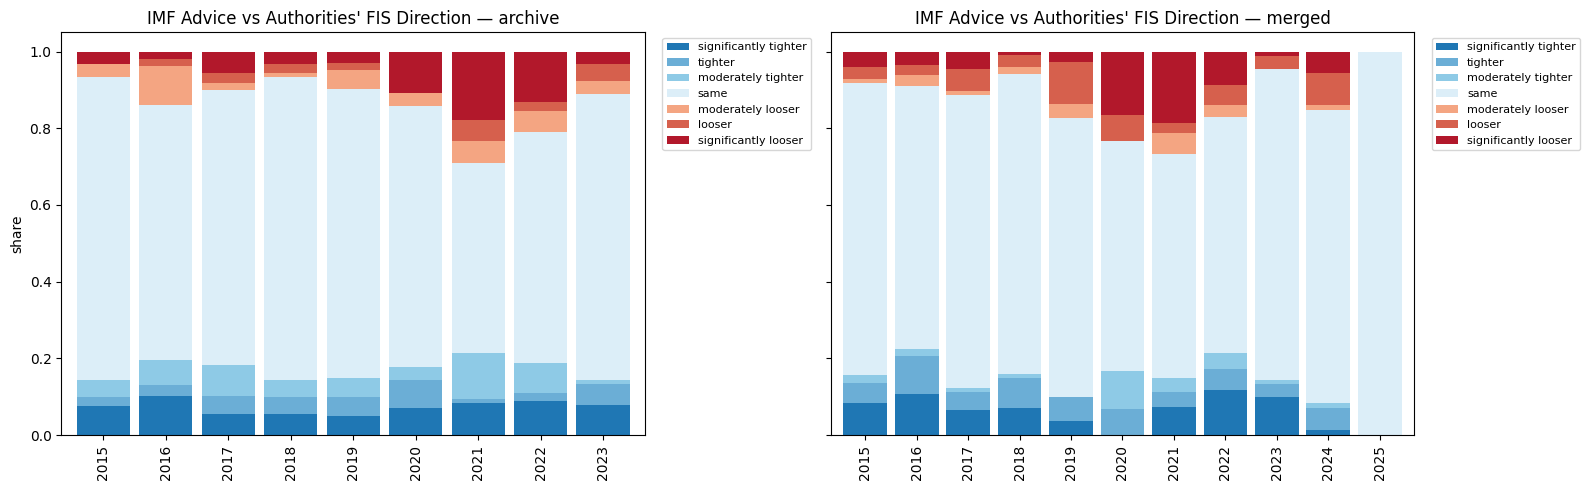

In [302]:
# --- Fiscal sector ---
run_sector_analysis(df_arc, df_new, sector_prefix='fis', stance_col='near_term')

## 6 · Policy mix (monetary × fiscal)

Cross-tab of monetary-future stance × fiscal-near-term stance, separately for
staff and for authorities. Maps each (mon, fis) pair to a 9-cell label
(`MtFt`, `MnFt`, ..., `MlFl`) and plots the yearly share. Skips the
CPA-benchmark confusion matrix (`mp_future_staff_bm_m` not in the dataset).

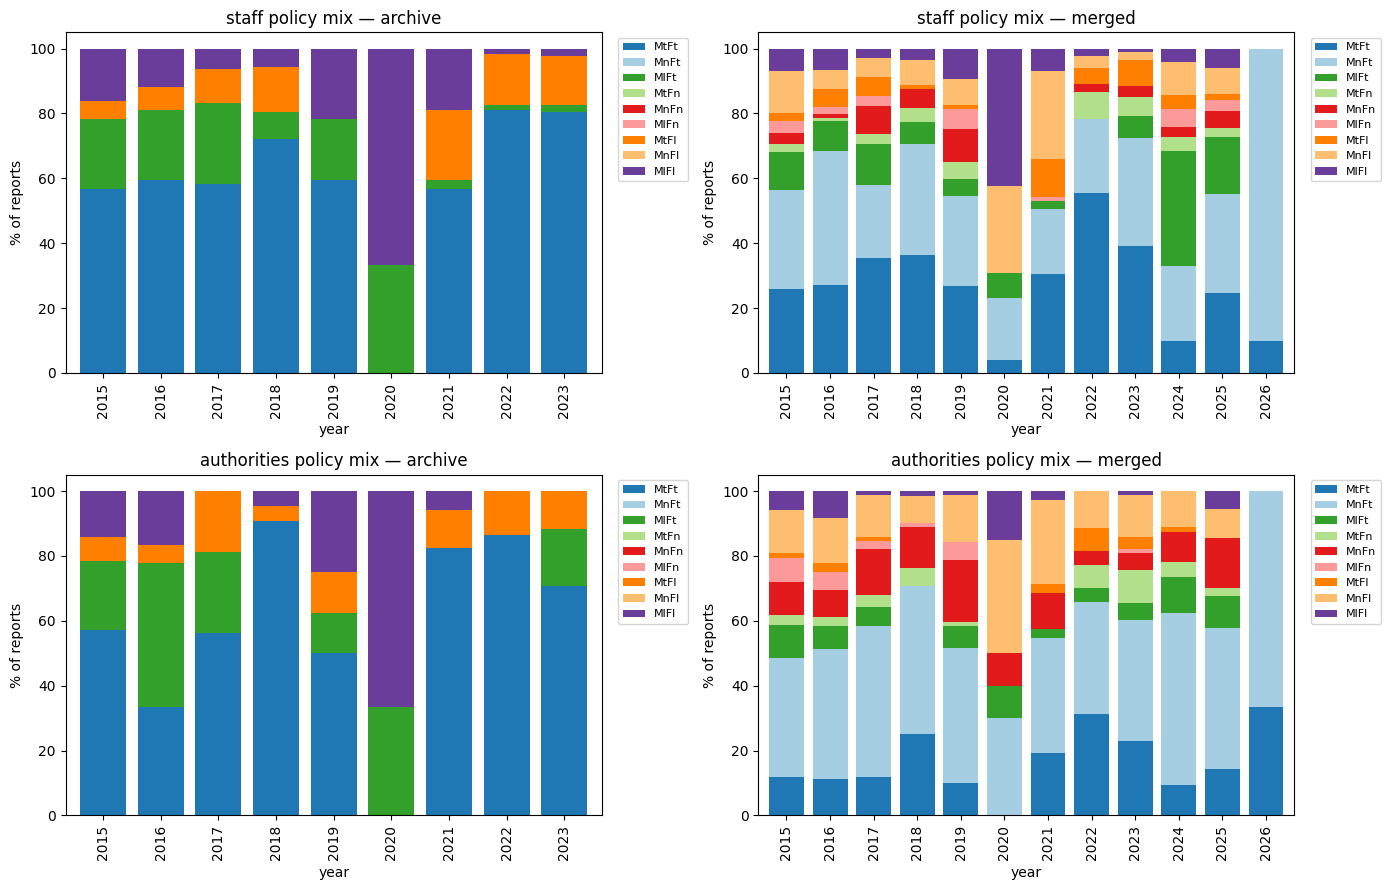

In [23]:
# --- Build policy-mix labels ---
MON_SHORT = {'tightening': 't', 'tightening bias': 't', 'no change': 'n', 'unclear': 'n',
             'loosening bias': 'l', 'loosening': 'l'}
FIS_SHORT = MON_SHORT  # same coding for fiscal near-term

def _policy_mix(row, mon_col, fis_col):
    m = MON_SHORT.get(str(row.get(mon_col, '')).strip().lower())
    f = FIS_SHORT.get(str(row.get(fis_col, '')).strip().lower())
    if m is None or f is None: return None
    return f'M{m}F{f}'.replace('Mt', 'Mt').replace('Mn', 'Mn').replace('Ml', 'Ml')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col_idx, (name, d) in enumerate([('archive', df_arc), ('merged', df_new)]):
    sub = d.copy()
    sub = dvu.coerce_year_int(sub)
    sub['policy_mix_staff'] = sub.apply(lambda r: _policy_mix(r, 'mon_stance_future_gpt_ft_staff', 'fis_stance_near_term_gpt_ft_staff'), axis=1)
    sub['policy_mix_buff']  = sub.apply(lambda r: _policy_mix(r, 'mon_stance_future_gpt_ft_buff',  'fis_stance_near_term_gpt_ft_buff'),  axis=1)
    for row_idx, (kind, col) in enumerate([('staff', 'policy_mix_staff'), ('authorities', 'policy_mix_buff')]):
        ax = axes[row_idx, col_idx]
        tab = sub.dropna(subset=[col]).groupby(['year', col]).size().unstack(fill_value=0)
        tab = tab.reindex(columns=POLICY_MIX_9, fill_value=0)
        if tab.empty:
            ax.text(0.5, 0.5, '(no data)', transform=ax.transAxes, ha='center'); continue
        (tab.div(tab.sum(axis=1), axis=0) * 100).plot.bar(stacked=True, ax=ax,
                                                            color=[colors_cate[i % len(colors_cate)] for i in range(9)],
                                                            width=0.8)
        ax.set_title(f'{kind} policy mix — {name}')
        ax.set_ylabel('% of reports')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()